# Assignment 4: Training a DCGAN on the Fashion-MNIST Dataset

Course: Generative AI

Name: Keerthi N

Reg No: 2411021240024

Department: Computer Application

University: Alliance University



## Objective

The objective of this assignment is to understand how a Deep Convolutional Generative Adversarial Network (DCGAN) is trained and how the generator and discriminator improve during training.

In this experiment, a DCGAN is implemented using TensorFlow and trained on the Fashion-MNIST dataset. The generator creates new fashion images from random noise, while the discriminator learns to distinguish between real and generated images.

The generated images are observed at different epochs to study the improvement in image quality and the training behavior of the GAN.

In [ ]:
!pip install -q tensorflow

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

print("TensorFlow version:", tf.__version__)
print("Available GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
Available GPU: []


## Basic Parameters

The DCGAN uses random noise as input to the generator. The Fashion-MNIST images are grayscale images of size 28 × 28 pixels.

For faster CPU training, a smaller subset of the dataset is used while keeping the required 25 training epochs.

In [ ]:
# Basic parameters
BUFFER_SIZE = 10000
BATCH_SIZE = 128
EPOCHS = 25
NOISE_DIM = 100

print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Noise Dimension:", NOISE_DIM)

Batch Size: 128
Epochs: 25
Noise Dimension: 100


## Loading the Fashion-MNIST Dataset

Fashion-MNIST contains grayscale images of clothing items such as shirts, shoes, trousers, bags, and dresses.

The original pixel values range from 0 to 255. Since the generator uses a Tanh activation function in its final layer, the images are normalized to the range -1 to 1.

In [ ]:
# Load Fashion-MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

print("Original dataset shape:", x_train.shape)

# Use 10,000 images for faster CPU training
x_train = x_train[:10000]

# Add channel dimension
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

# Normalize images from [0, 255] to [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

print("Training images used:", x_train.shape)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original dataset shape: (60000, 28, 28)
Training images used: (10000, 28, 28, 1)
Minimum pixel value: -1.0
Maximum pixel value: 1.0


In [ ]:
# Create TensorFlow dataset
train_dataset = tf.data.Dataset.from_tensor_slices(x_train)

train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("Dataset created successfully.")

Dataset created successfully.


## Original Fashion-MNIST Images

Before training the DCGAN, a few real Fashion-MNIST images are displayed. These images will be used as a reference for comparing the generated images during training.

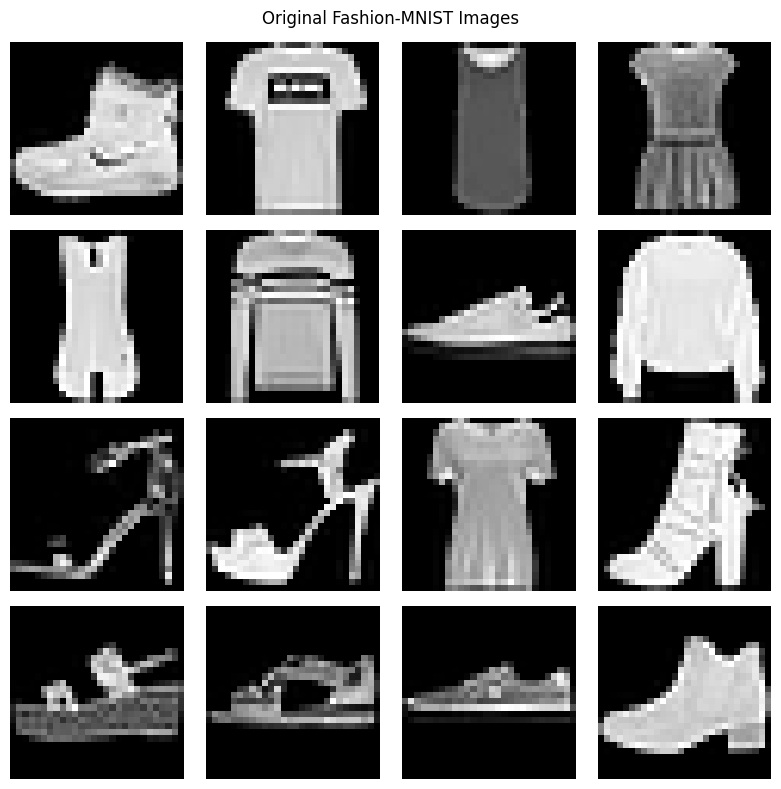

In [ ]:
# Display original images
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow((x_train[i] + 1) / 2, cmap="gray")
    plt.axis("off")

plt.suptitle("Original Fashion-MNIST Images")
plt.tight_layout()
plt.show()

## Building the Generator

The generator takes a random noise vector as input and gradually converts it into a 28 × 28 grayscale image.

Transposed convolution layers are used to increase the spatial size of the image. The generator starts with random noise and progressively produces a more detailed image.

The final Tanh activation produces pixel values in the range -1 to 1.

In [ ]:
def build_generator():

    model = tf.keras.Sequential(name="Generator")

    model.add(
        tf.keras.layers.Dense(
            7 * 7 * 128,
            use_bias=False,
            input_shape=(NOISE_DIM,)
        )
    )

    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    model.add(
        tf.keras.layers.Reshape((7, 7, 128))
    )

    # 7x7 -> 14x14
    model.add(
        tf.keras.layers.Conv2DTranspose(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    # 14x14 -> 28x28
    model.add(
        tf.keras.layers.Conv2DTranspose(
            1,
            kernel_size=5,
            strides=2,
            padding="same",
            activation="tanh"
        )
    )

    return model


generator = build_generator()

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 858,945 (3.28 MB)

 Trainable params: 846,273 (3.23 MB)

 Non-trainable params: 12,672 (49.50 KB)

## Testing the Generator Before Training

Before training, the generator receives random noise and produces images. Since the generator has not learned the Fashion-MNIST patterns yet, the output is expected to look like random or unclear shapes.

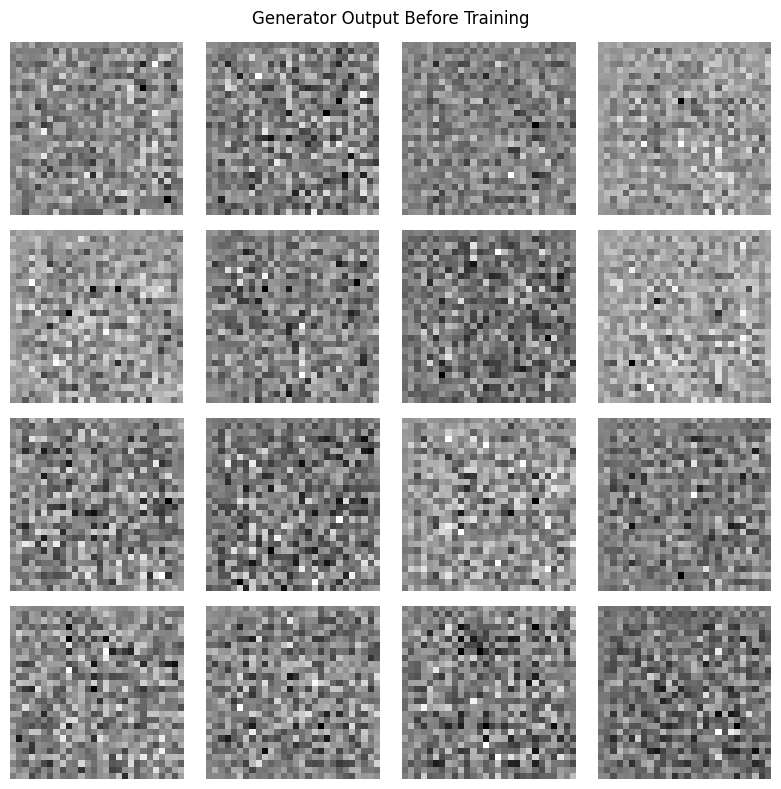

In [ ]:
# Generate random noise
noise = tf.random.normal([16, NOISE_DIM])

# Generate images
generated_images = generator(noise, training=False)

# Display generated images
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow((generated_images[i] + 1) / 2, cmap="gray")
    plt.axis("off")

plt.suptitle("Generator Output Before Training")
plt.tight_layout()
plt.show()

## Building the Discriminator

The discriminator receives a 28 × 28 grayscale image and predicts whether the image is real or generated.

Convolutional layers are used to extract image features. The final sigmoid layer produces a probability between 0 and 1.

A value close to 1 indicates a real image, while a value close to 0 indicates a generated image.

In [ ]:
def build_discriminator():

    model = tf.keras.Sequential(name="Discriminator")

    model.add(
        tf.keras.layers.Conv2D(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            input_shape=(28, 28, 1)
        )
    )

    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(
        tf.keras.layers.Conv2D(
            128,
            kernel_size=5,
            strides=2,
            padding="same"
        )
    )

    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Flatten())

    model.add(
        tf.keras.layers.Dense(1, activation="sigmoid")
    )

    return model


discriminator = build_discriminator()

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Test discriminator with one real image
real_image = x_train[0:1]

prediction = discriminator(real_image)

print("Discriminator prediction:", prediction.numpy())

Discriminator prediction: [[0.4933624]]


## Loss Functions and Optimizers

Binary Cross Entropy is used as the loss function because the discriminator performs a binary classification task: real or fake.

The discriminator tries to correctly classify real and generated images, while the generator tries to generate images that the discriminator classifies as real.

Adam optimizer is used for both networks.

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=False
)


def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss


def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )


generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

print("Loss functions and optimizers are ready.")

Loss functions and optimizers are ready.


## Fixed Noise for Image Comparison

A fixed set of random noise vectors is created so that the same input can be given to the generator after every 5 epochs.

This makes it easier to observe how the generated images change as training progresses.

In [ ]:
seed = tf.random.normal([16, NOISE_DIM])

print("Fixed noise created.")

Fixed noise created.


## Training Step

During each training step, the discriminator first learns from real and generated images.

Then the generator is trained to produce images that can fool the discriminator.

Both networks are updated using their respective gradients.

In [ ]:
@tf.function
def train_step(images):

    # Generate random noise
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    # -------------------------
    # Train Discriminator
    # -------------------------
    with tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    discriminator_optimizer.apply_gradients(
        zip(
            disc_gradients,
            discriminator.trainable_variables
        )
    )

    # -------------------------
    # Train Generator
    # -------------------------
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape:

        generated_images = generator(
            noise,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gen_gradients,
            generator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [ ]:
def generate_and_save_images(model, epoch, test_input):

    predictions = model(
        test_input,
        training=False
    )

    plt.figure(figsize=(8, 8))

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            (predictions[i] + 1) / 2,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Generated Fashion-MNIST Images - Epoch {epoch}"
    )

    plt.tight_layout()

    plt.savefig(
        f"generated_epoch_{epoch}.png"
    )

    plt.show()

## Training the DCGAN

The DCGAN is trained for 25 epochs. The generator and discriminator losses are recorded after every epoch.

A 4 × 4 grid of generated images is displayed after every 5 epochs to observe the improvement in image quality.

Epoch 1/25 | Generator Loss: 0.7527 | Discriminator Loss: 1.1529 | Time: 82.0s
Epoch 2/25 | Generator Loss: 0.7491 | Discriminator Loss: 1.3221 | Time: 69.2s
Epoch 3/25 | Generator Loss: 0.7647 | Discriminator Loss: 1.3563 | Time: 69.3s
Epoch 4/25 | Generator Loss: 0.7723 | Discriminator Loss: 1.3343 | Time: 68.6s
Epoch 5/25 | Generator Loss: 0.7801 | Discriminator Loss: 1.3125 | Time: 68.7s


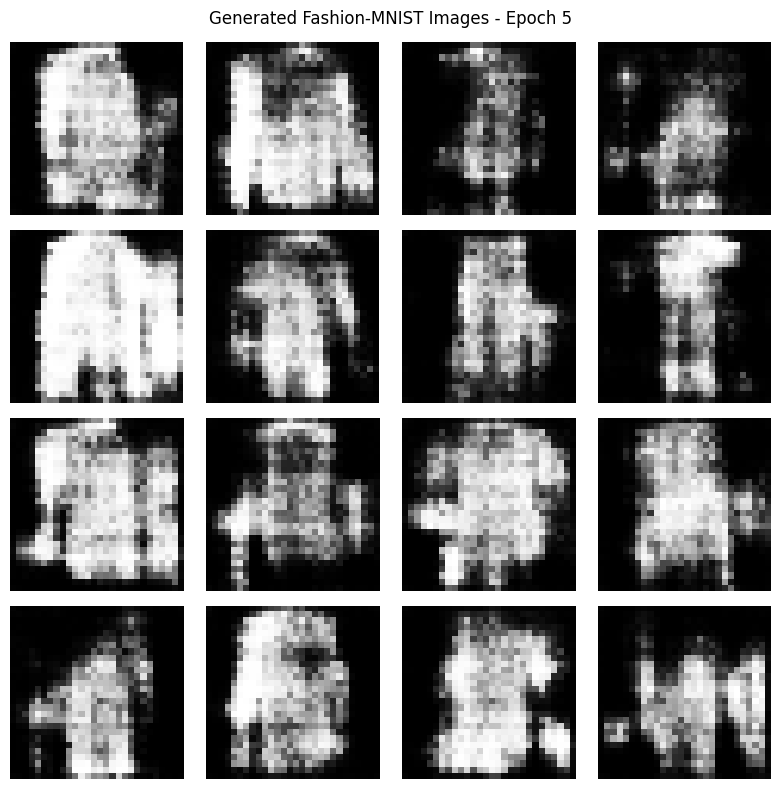

Epoch 6/25 | Generator Loss: 0.8223 | Discriminator Loss: 1.2795 | Time: 69.5s
Epoch 7/25 | Generator Loss: 0.8853 | Discriminator Loss: 1.2301 | Time: 69.3s
Epoch 8/25 | Generator Loss: 0.9502 | Discriminator Loss: 1.1784 | Time: 68.6s
Epoch 9/25 | Generator Loss: 1.0159 | Discriminator Loss: 1.1304 | Time: 68.6s
Epoch 10/25 | Generator Loss: 1.0668 | Discriminator Loss: 1.0783 | Time: 68.7s


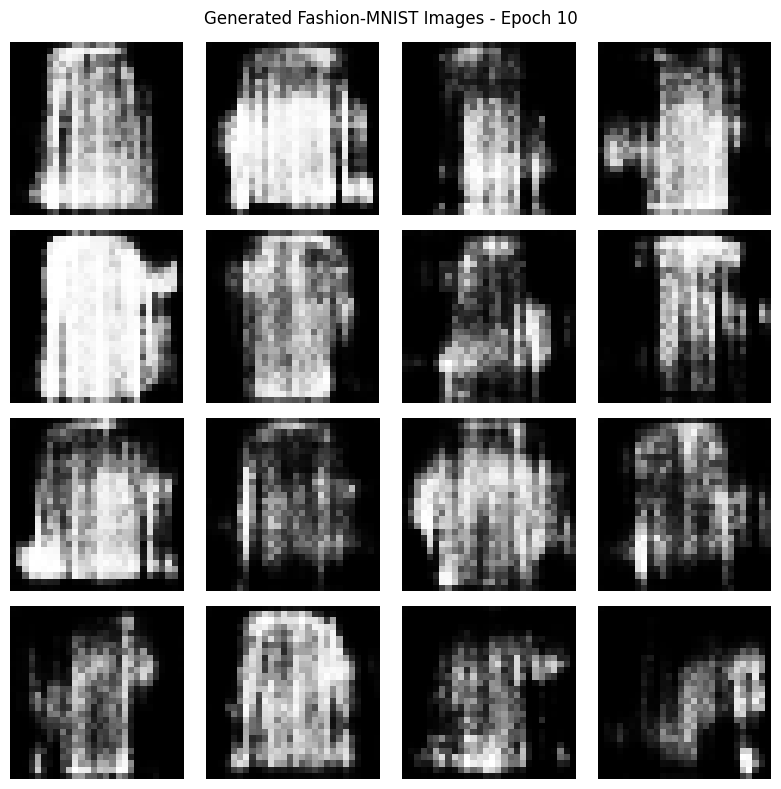

Epoch 11/25 | Generator Loss: 1.0779 | Discriminator Loss: 1.0480 | Time: 70.1s
Epoch 12/25 | Generator Loss: 1.1205 | Discriminator Loss: 1.0415 | Time: 69.2s
Epoch 13/25 | Generator Loss: 1.1025 | Discriminator Loss: 1.0521 | Time: 68.8s
Epoch 14/25 | Generator Loss: 1.0854 | Discriminator Loss: 1.0618 | Time: 68.8s
Epoch 15/25 | Generator Loss: 1.1366 | Discriminator Loss: 1.0957 | Time: 68.9s


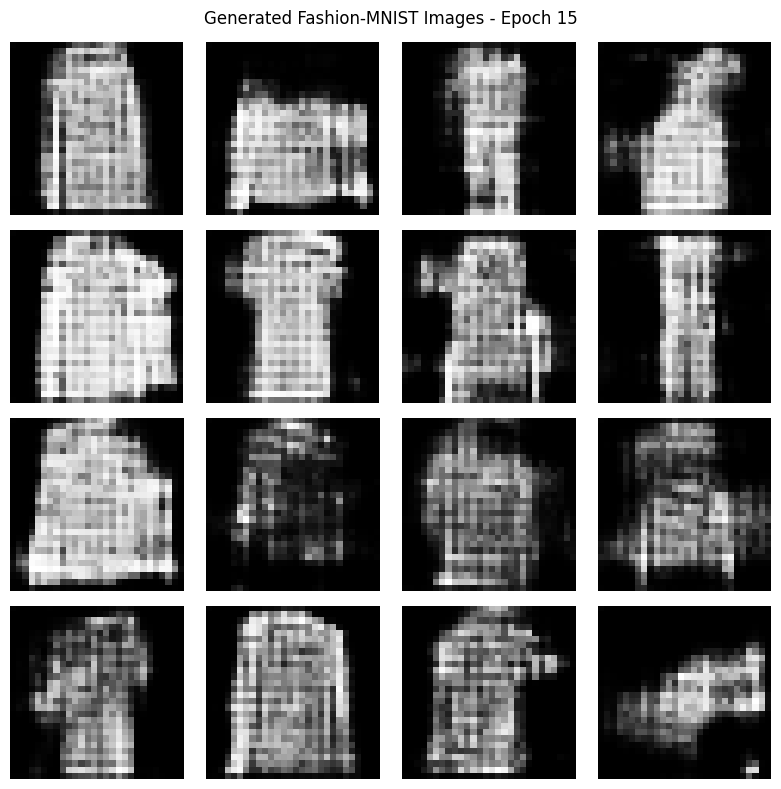

Epoch 16/25 | Generator Loss: 1.0703 | Discriminator Loss: 1.0971 | Time: 70.0s
Epoch 17/25 | Generator Loss: 1.0577 | Discriminator Loss: 1.0939 | Time: 69.2s
Epoch 18/25 | Generator Loss: 1.0495 | Discriminator Loss: 1.0966 | Time: 69.0s
Epoch 19/25 | Generator Loss: 1.0342 | Discriminator Loss: 1.1293 | Time: 69.6s
Epoch 20/25 | Generator Loss: 1.0384 | Discriminator Loss: 1.1140 | Time: 69.5s


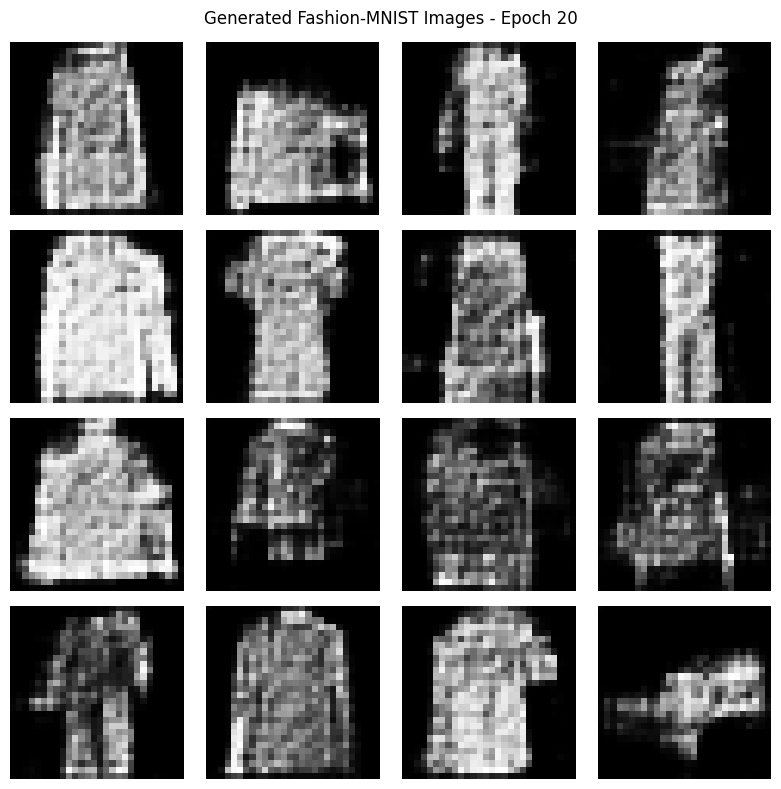

Epoch 21/25 | Generator Loss: 1.0523 | Discriminator Loss: 1.1346 | Time: 70.6s
Epoch 22/25 | Generator Loss: 1.0279 | Discriminator Loss: 1.1310 | Time: 70.0s
Epoch 23/25 | Generator Loss: 1.0133 | Discriminator Loss: 1.1233 | Time: 70.0s
Epoch 24/25 | Generator Loss: 1.0148 | Discriminator Loss: 1.1440 | Time: 69.4s
Epoch 25/25 | Generator Loss: 1.0098 | Discriminator Loss: 1.1538 | Time: 70.6s


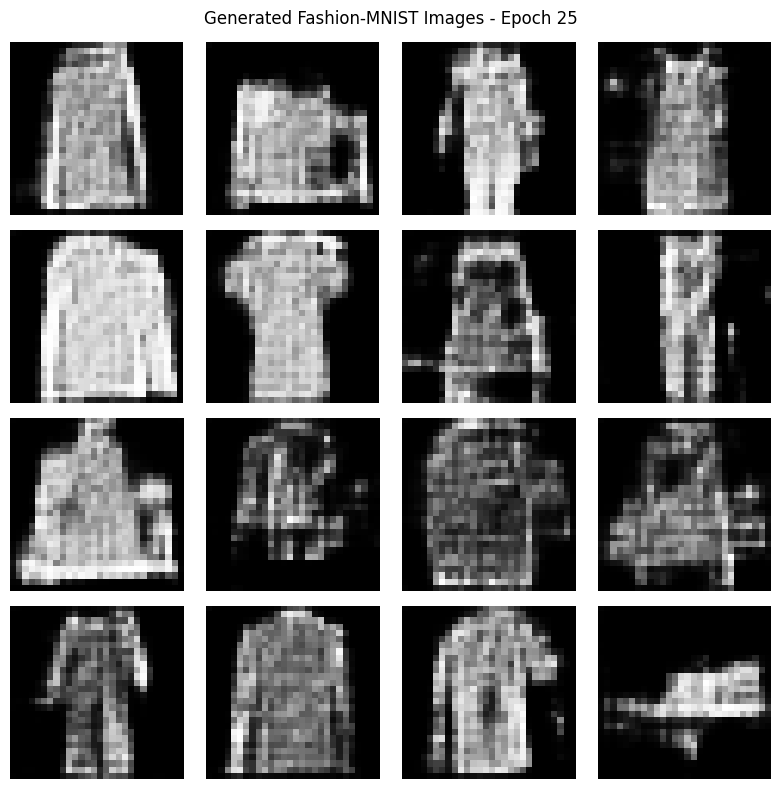


Total training time: 29.14 minutes


In [ ]:
generator_losses = []
discriminator_losses = []
saved_epochs = []

start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    gen_loss_total = 0
    disc_loss_total = 0
    batch_count = 0

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(image_batch)

        gen_loss_total += float(gen_loss)
        disc_loss_total += float(disc_loss)

        batch_count += 1

    # Average losses
    avg_gen_loss = gen_loss_total / batch_count
    avg_disc_loss = disc_loss_total / batch_count

    generator_losses.append(avg_gen_loss)
    discriminator_losses.append(avg_disc_loss)

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # Generate images every 5 epochs
    if epoch % 5 == 0:

        saved_epochs.append(epoch)

        generate_and_save_images(
            generator,
            epoch,
            seed
        )

total_time = time.time() - start_time

print(
    f"\nTotal training time: "
    f"{total_time / 60:.2f} minutes"
)

## Generator Loss

The generator loss shows how well the generator is able to fool the discriminator during training.

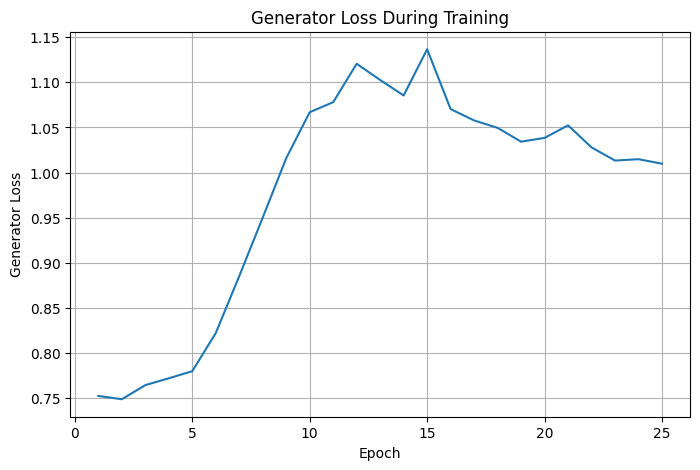

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    generator_losses
)

plt.xlabel("Epoch")
plt.ylabel("Generator Loss")
plt.title("Generator Loss During Training")
plt.grid()

plt.show()

## Discriminator Loss

The discriminator loss shows how well the discriminator distinguishes between real Fashion-MNIST images and generated images.

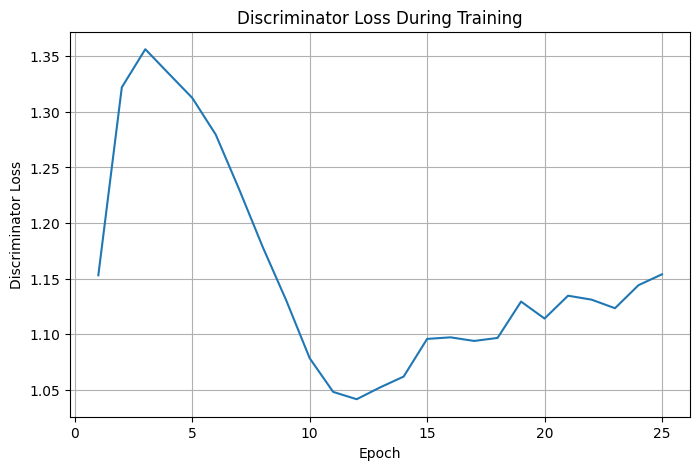

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    discriminator_losses
)

plt.xlabel("Epoch")
plt.ylabel("Discriminator Loss")
plt.title("Discriminator Loss During Training")
plt.grid()

plt.show()

## Generator and Discriminator Loss Comparison

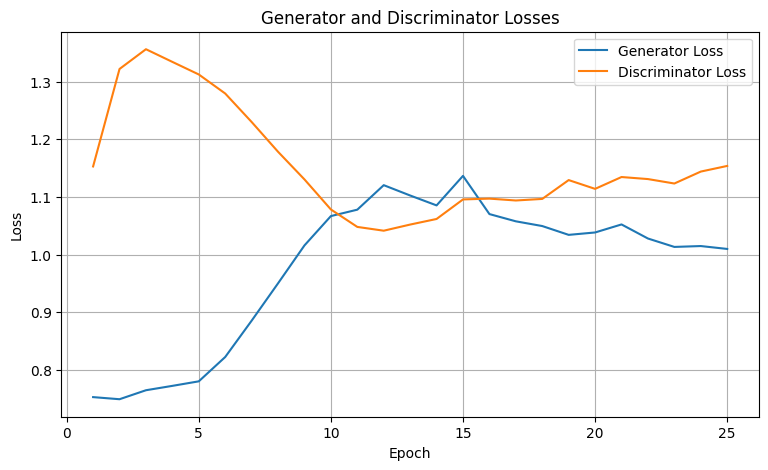

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, EPOCHS + 1),
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Losses")

plt.legend()
plt.grid()

plt.show()

## Final Generated Images

After completing 25 epochs, the trained generator is used to produce a final 4 × 4 grid of Fashion-MNIST-like images.

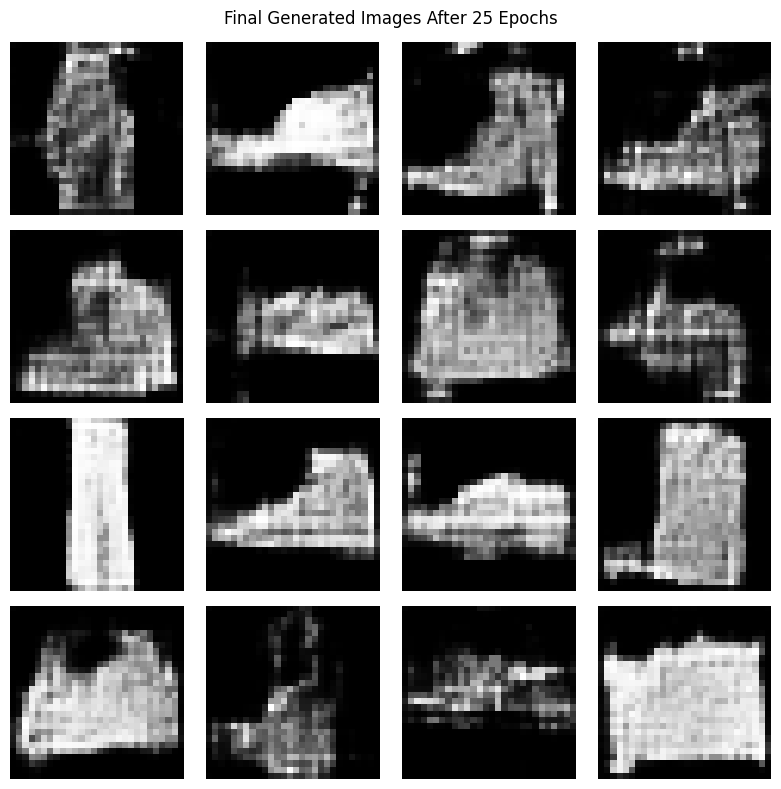

In [ ]:
final_noise = tf.random.normal([16, NOISE_DIM])

final_images = generator(
    final_noise,
    training=False
)

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        (final_images[i] + 1) / 2,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Final Generated Images After 25 Epochs")
plt.tight_layout()
plt.show()

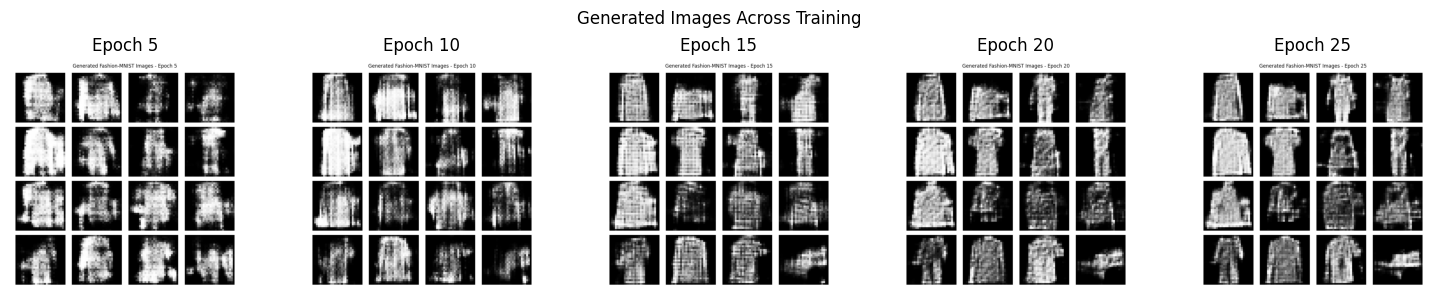

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, epoch in enumerate(saved_epochs):

    image = plt.imread(
        f"generated_epoch_{epoch}.png"
    )

    axes[i].imshow(image)
    axes[i].set_title(f"Epoch {epoch}")
    axes[i].axis("off")

plt.suptitle("Generated Images Across Training")
plt.tight_layout()
plt.show()

## Overall Training Analysis

The DCGAN was trained for 25 epochs on the Fashion-MNIST dataset. The generated images were saved after every 5 epochs to observe the progress of the generator.

At the beginning of training, the generated images were mostly random and did not have a clear clothing structure. As training progressed, the generator gradually learned patterns such as edges, shapes, and outlines from the Fashion-MNIST images.

By the later epochs, the generated images became more structured and some of them started to resemble clothing items. The overall image quality improved compared with the early training stages.

The generator and discriminator losses did not decrease continuously. Instead, they fluctuated because both networks were learning and competing with each other. This behavior is normal in GAN training.

Overall, the experiment showed that the generator gradually learned to create Fashion-MNIST-like images from random noise.

# **Questions**

## 1. How do the images change from Epoch 5 to Epoch 25?

At Epoch 5, the generated images mostly contain random patterns, noise, and unclear shapes because the generator has only started learning from the Fashion-MNIST dataset. As training progresses, the generator gradually learns important features such as edges, outlines, shapes, and structures of different clothing items. Around the middle epochs, some generated images begin to show recognizable clothing-like patterns. By Epoch 25, the images are generally more structured and clearer compared to the early epochs. Some images may resemble shoes, shirts, trousers, or bags, although they may still contain some noise and imperfections.

## 2. Can you observe instability in training?

Yes, some instability can be observed during the training of the DCGAN. The generator and discriminator continuously compete with each other, which causes their loss values to increase and decrease at different stages of training. The quality of the generated images may also change unevenly between epochs. For example, an image may appear clearer in one epoch and slightly distorted in the next epoch. This happens because the discriminator becomes better at identifying fake images while the generator tries to improve its ability to fool the discriminator. Such fluctuations are common during GAN training and do not necessarily indicate that the model has failed.

## 3. At which epoch do clothes-like shapes become recognizable?

Clothing-like shapes generally start becoming recognizable during the middle stages of training, approximately around Epoch 10 to Epoch 15. At this stage, the generator has learned some of the basic visual patterns and structures present in the Fashion-MNIST dataset. Generated images may begin to resemble items such as shoes, shirts, trousers, bags, and other clothing objects. As training continues toward Epoch 20 and Epoch 25, these shapes generally become more defined and easier to identify. The exact epoch can vary depending on the training conditions and the results obtained from the model.

## 4. Does the image quality continue improving throughout the training?

The image quality generally improves as the training progresses from Epoch 5 toward Epoch 25. During the early stages, the generated images mainly contain random noise and do not have a clear structure. As the generator learns from the real Fashion-MNIST images, it becomes better at producing meaningful shapes and clothing-like patterns. In the later epochs, the generated images are usually more organized and recognizable than the earlier outputs. However, the improvement is not always smooth because GAN training can be unstable. Some images may temporarily become less clear, but the overall quality shows improvement throughout the training.

## 5. What happens to the generator and discriminator losses?

The generator and discriminator losses fluctuate throughout the training process because both networks are learning and competing against each other. The generator loss indicates how well the generator is able to create fake images that can fool the discriminator, while the discriminator loss indicates how well it can distinguish between real and generated images. Unlike a normal classification model, the losses in a GAN do not necessarily decrease continuously. They may increase or decrease at different epochs depending on which network is learning more effectively at that stage. Therefore, the loss graphs should be studied together with the generated image grids to understand whether the model is learning properly. In this experiment, the fluctuations in the losses reflect the competitive learning process between the generator and discriminator.

## Conclusion

In this assignment, a Deep Convolutional Generative Adversarial Network (DCGAN) was implemented using TensorFlow and trained on the Fashion-MNIST dataset. The model consisted of two main networks: a Generator and a Discriminator. The Generator used transposed convolution layers to create new 28 × 28 grayscale images from random noise, while the Discriminator used convolution layers to distinguish between real and generated images.

The DCGAN was trained for 25 epochs, and the generated images were observed at regular intervals of 5 epochs. The results showed that the images changed from random and unclear patterns during the early stages to more structured and recognizable clothing-like shapes in the later stages.

The Generator and Discriminator losses fluctuated during training because both networks continuously competed with each other. By comparing the generated images and loss graphs, it was possible to understand how the model learned to generate images similar to the Fashion-MNIST dataset.

Overall, this experiment helped demonstrate the working process of GANs and how deep convolutional networks can be used to generate new images from random noise.